<a href="https://colab.research.google.com/github/mahla-aghapour/B101-Group2-NLP-Project/blob/main/CasualInitialTraining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Casual Initial training

In [1]:
!pip install -q transformers datasets sentencepiece accelerate scikit-learn matplotlib pandas

GPU: Tesla T4


Saving informal_samples.csv to informal_samples.csv
Dataset shape: (5400, 3)

Label distribution:
AI_label
0    2700
1    2700
Name: count, dtype: int64


Stringifying the column:   0%|          | 0/5400 [00:00<?, ? examples/s]

Casting to class labels:   0%|          | 0/5400 [00:00<?, ? examples/s]


Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 4320
    })
    val: Dataset({
        features: ['sample_text', 'sub-type', 'AI_label'],
        num_rows: 1080
    })
})


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,F1
0.000431,0.024249,4,0.993519,0.993525



Final/best validation metrics:
{'eval_loss': 0.024248765781521797, 'eval_accuracy': 0.9935185185185185, 'eval_f1': 0.9935245143385754}


,run,eval_accuracy,eval_f1,eval_loss
0,No forced model dtype,0.500000,0.000000,NaN
1,Forced model dtype: FP32,0.993519,0.993525,0.024249


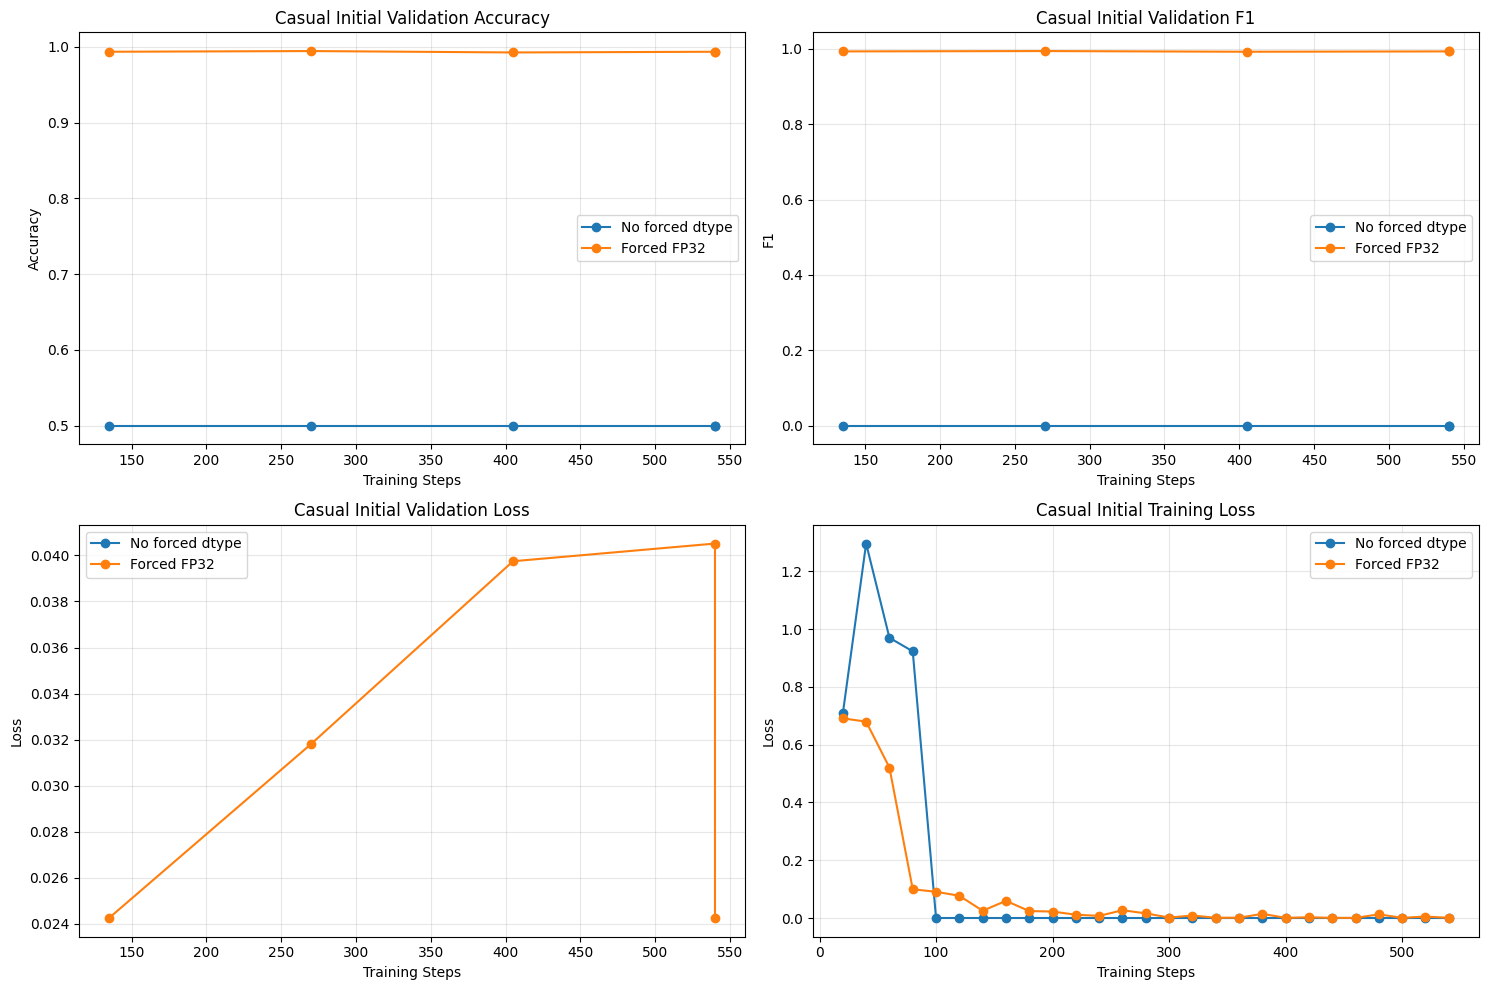

Created: /content/casual_initial_results.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import os
import gc
import shutil
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files
from datasets import Dataset
from sklearn.metrics import accuracy_score, f1_score

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed
)

# ============================================================
# CHECK GPU
# ============================================================

if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU is not enabled. Select Runtime > Change runtime type > T4 GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))

# ============================================================
# UPLOAD CASUAL TRAINING DATA ONLY
# ============================================================

uploaded = files.upload()

CSV_PATH = "/content/informal_samples.csv"

df = pd.read_csv(CSV_PATH, encoding="latin-1")

required_columns = {"sample_text", "AI_label"}

if not required_columns.issubset(df.columns):
    raise ValueError(
        f"CSV must contain {required_columns}. Found: {list(df.columns)}"
    )

df["AI_label"] = pd.to_numeric(df["AI_label"]).astype(int)

if set(df["AI_label"].unique()) != {0, 1}:
    raise ValueError("AI_label must contain only 0 and 1.")

print("Dataset shape:", df.shape)
print("\nLabel distribution:")
print(df["AI_label"].value_counts().sort_index())

# ============================================================
# SAME 80/20 INTERNAL SPLIT AS KC'S INITIAL SETUP
# ============================================================

raw_dataset = Dataset.from_pandas(df, preserve_index=False)
raw_dataset = raw_dataset.class_encode_column("AI_label")

dataset = raw_dataset.train_test_split(
    test_size=0.20,
    seed=42,
    shuffle=True,
    stratify_by_column="AI_label"
)

dataset["val"] = dataset.pop("test")

print("\nDataset splits:")
print(dataset)

# Expected for 5,400 samples:
# train = 4,320
# val = 1,080

# ============================================================
# TOKENIZATION
# ============================================================

CHECKPOINT = "microsoft/deberta-v3-small"
MAX_LENGTH = 350

tokenizer = AutoTokenizer.from_pretrained(
    CHECKPOINT,
    use_fast=True
)

def tokenize(examples):
    tokenized = tokenizer(
        examples["sample_text"],
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    tokenized["labels"] = examples["AI_label"]
    return tokenized

tokenized_dataset = dataset.map(
    tokenize,
    batched=True,
    remove_columns=dataset["train"].column_names
)

print(tokenized_dataset)

# ============================================================
# ORIGINAL EARLY METRICS: ACCURACY AND BINARY F1
# No F1-macro because KC said it was not in the early setup.
# ============================================================

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(
            labels,
            predictions,
            average="binary",
            zero_division=0
        )
    }

# ============================================================
# RUN FUNCTION
# ============================================================

def run_initial_experiment(run_name, force_float32):
    print("\n" + "=" * 65)
    print("RUN:", run_name)
    print("Force model loading dtype to float32:", force_float32)
    print("=" * 65)

    gc.collect()
    torch.cuda.empty_cache()
    set_seed(42)

    model_parameters = {
        "pretrained_model_name_or_path": CHECKPOINT,
        "num_labels": 2,
        "id2label": {
            0: "Human-Written",
            1: "AI-Generated"
        },
        "label2id": {
            "Human-Written": 0,
            "AI-Generated": 1
        }
    }

    # This is the only difference between the two experiments.
    if force_float32:
        model_parameters["dtype"] = torch.float32

    model = AutoModelForSequenceClassification.from_pretrained(
        **model_parameters
    )

    training_args = TrainingArguments(
        seed=42,
        output_dir=f"/content/{run_name}",
        report_to="none",

        # KC's preliminary configuration
        num_train_epochs=4,
        per_device_train_batch_size=32,
        per_device_eval_batch_size=32,
        learning_rate=2e-5,
        weight_decay=0.05,

        lr_scheduler_type="linear",
        warmup_steps=50,

        # One evaluation at the end of each epoch
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=2,

        logging_strategy="steps",
        logging_steps=20,

        max_grad_norm=1.0,
        fp16=False,
        bf16=False,

        metric_for_best_model="eval_loss",
        greater_is_better=False,
        load_best_model_at_end=True
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["val"],
        compute_metrics=compute_metrics
    )

    trainer.train()

    final_metrics = trainer.evaluate()
    history = list(trainer.state.log_history)

    trainer.save_state()

    print("\nFinal/best validation metrics:")
    print(final_metrics)

    del trainer
    del model

    gc.collect()
    torch.cuda.empty_cache()

    return final_metrics, history

# ============================================================
# RUN 1: ORIGINAL SETUP WITHOUT FORCED DTYPE
# ============================================================

broken_metrics, broken_history = run_initial_experiment(
    run_name="casual_initial_no_forced_dtype",
    force_float32=False
)

# ============================================================
# RUN 2: SAME SETUP, BUT MODEL IS EXPLICITLY LOADED AS FP32
# ============================================================

fixed_metrics, fixed_history = run_initial_experiment(
    run_name="casual_initial_forced_fp32",
    force_float32=True
)

# ============================================================
# SAVE SUMMARY
# ============================================================

artifact_dir = "/content/casual_initial_results"
os.makedirs(artifact_dir, exist_ok=True)

summary_df = pd.DataFrame([
    {
        "run": "No forced model dtype",
        "eval_accuracy": broken_metrics.get("eval_accuracy"),
        "eval_f1": broken_metrics.get("eval_f1"),
        "eval_loss": broken_metrics.get("eval_loss")
    },
    {
        "run": "Forced model dtype: FP32",
        "eval_accuracy": fixed_metrics.get("eval_accuracy"),
        "eval_f1": fixed_metrics.get("eval_f1"),
        "eval_loss": fixed_metrics.get("eval_loss")
    }
])

summary_df.to_csv(
    f"{artifact_dir}/casual_initial_summary.csv",
    index=False
)

display(summary_df)

pd.DataFrame(broken_history).to_csv(
    f"{artifact_dir}/no_forced_dtype_history.csv",
    index=False
)

pd.DataFrame(fixed_history).to_csv(
    f"{artifact_dir}/forced_fp32_history.csv",
    index=False
)

# ============================================================
# GRAPH GENERATION
# ============================================================

def get_eval_history(history):
    return pd.DataFrame([
        row for row in history
        if "eval_loss" in row
    ])

def get_train_history(history):
    return pd.DataFrame([
        row for row in history
        if "loss" in row and "eval_loss" not in row
    ])

broken_eval = get_eval_history(broken_history)
fixed_eval = get_eval_history(fixed_history)

broken_train = get_train_history(broken_history)
fixed_train = get_train_history(fixed_history)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Evaluation accuracy
axes[0, 0].plot(
    broken_eval["step"],
    broken_eval["eval_accuracy"],
    marker="o",
    label="No forced dtype"
)

axes[0, 0].plot(
    fixed_eval["step"],
    fixed_eval["eval_accuracy"],
    marker="o",
    label="Forced FP32"
)

axes[0, 0].set_title("Casual Initial Validation Accuracy")
axes[0, 0].set_xlabel("Training Steps")
axes[0, 0].set_ylabel("Accuracy")
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Evaluation F1
axes[0, 1].plot(
    broken_eval["step"],
    broken_eval["eval_f1"],
    marker="o",
    label="No forced dtype"
)

axes[0, 1].plot(
    fixed_eval["step"],
    fixed_eval["eval_f1"],
    marker="o",
    label="Forced FP32"
)

axes[0, 1].set_title("Casual Initial Validation F1")
axes[0, 1].set_xlabel("Training Steps")
axes[0, 1].set_ylabel("F1")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Evaluation loss
axes[1, 0].plot(
    broken_eval["step"],
    broken_eval["eval_loss"],
    marker="o",
    label="No forced dtype"
)

axes[1, 0].plot(
    fixed_eval["step"],
    fixed_eval["eval_loss"],
    marker="o",
    label="Forced FP32"
)

axes[1, 0].set_title("Casual Initial Validation Loss")
axes[1, 0].set_xlabel("Training Steps")
axes[1, 0].set_ylabel("Loss")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Training loss
axes[1, 1].plot(
    broken_train["step"],
    broken_train["loss"],
    marker="o",
    label="No forced dtype"
)

axes[1, 1].plot(
    fixed_train["step"],
    fixed_train["loss"],
    marker="o",
    label="Forced FP32"
)

axes[1, 1].set_title("Casual Initial Training Loss")
axes[1, 1].set_xlabel("Training Steps")
axes[1, 1].set_ylabel("Loss")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()

comparison_path = (
    f"{artifact_dir}/casual_initial_dtype_comparison.png"
)

plt.savefig(
    comparison_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================================================
# ZIP AND DOWNLOAD THE REPORT ARTIFACTS
# ============================================================

zip_path = shutil.make_archive(
    "/content/casual_initial_results",
    "zip",
    artifact_dir
)

print("Created:", zip_path)
files.download(zip_path)

NO FORCED DTYPE — EVALUATION LOGS


,step,eval_accuracy,eval_f1,eval_loss


FORCED FP32 — EVALUATION LOGS


,step,eval_accuracy,eval_f1,eval_loss
6,135,0.993519,0.993525,0.024249
14,270,0.994444,0.994465,0.031806
22,405,0.992593,0.992634,0.039748
30,540,0.993519,0.993548,0.040516



Generating graphs for: Casual prelim — no forced dtype


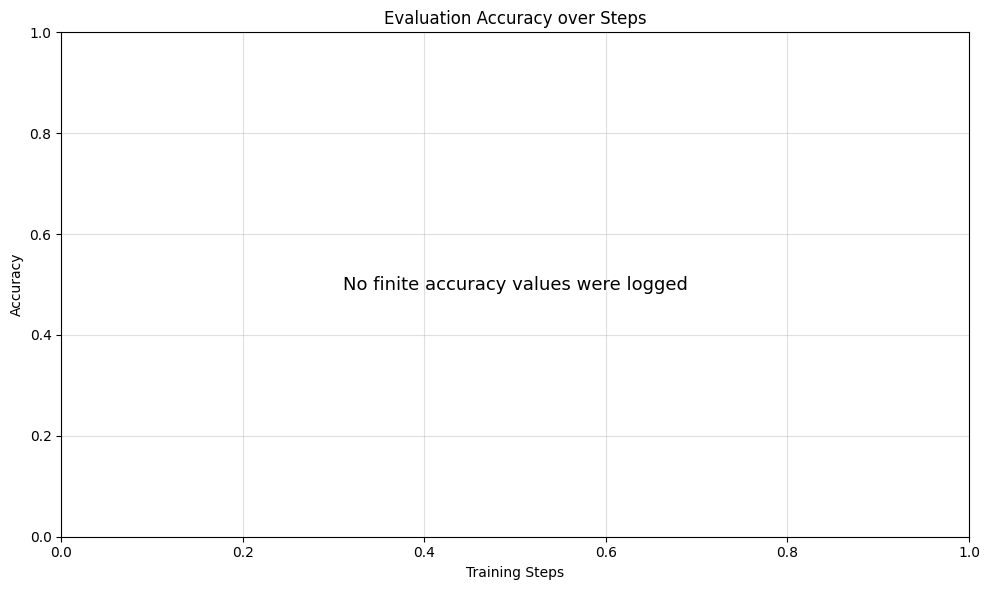

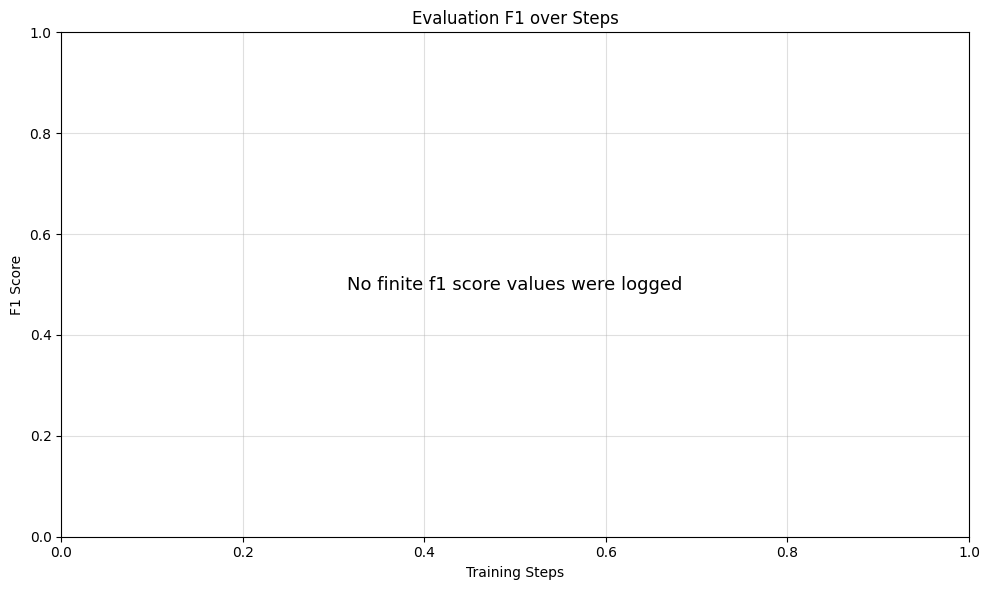

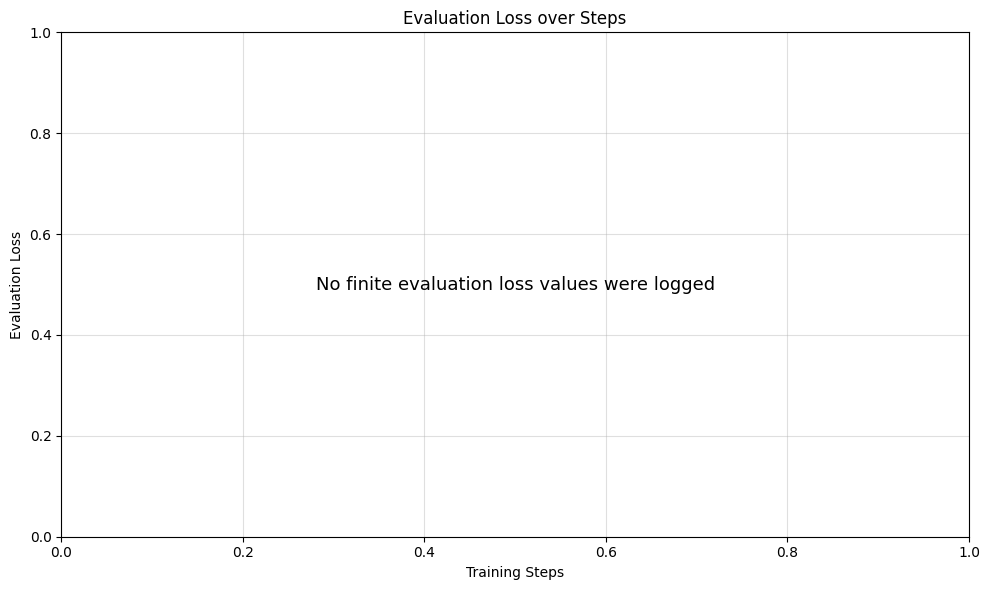

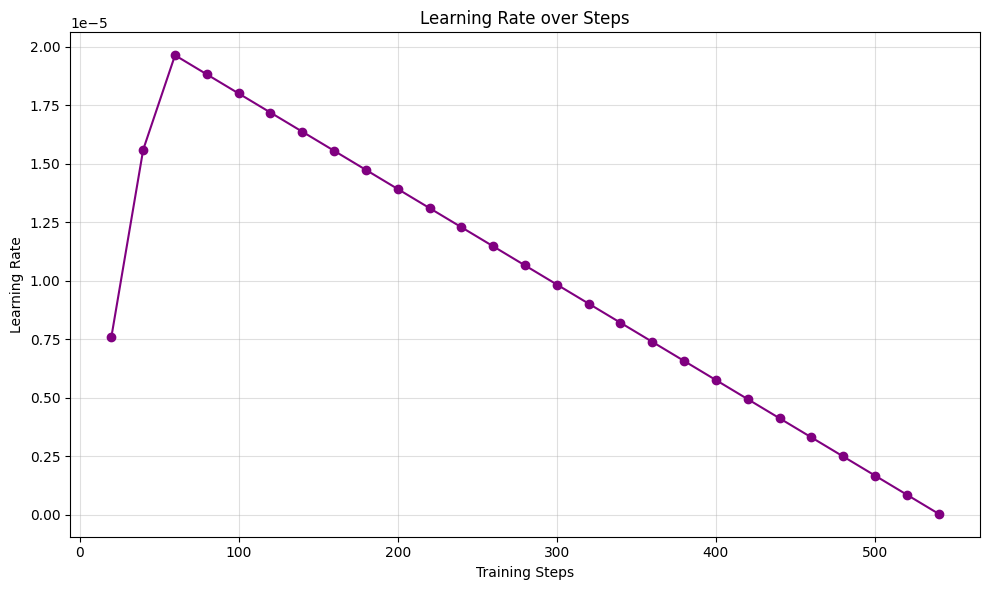

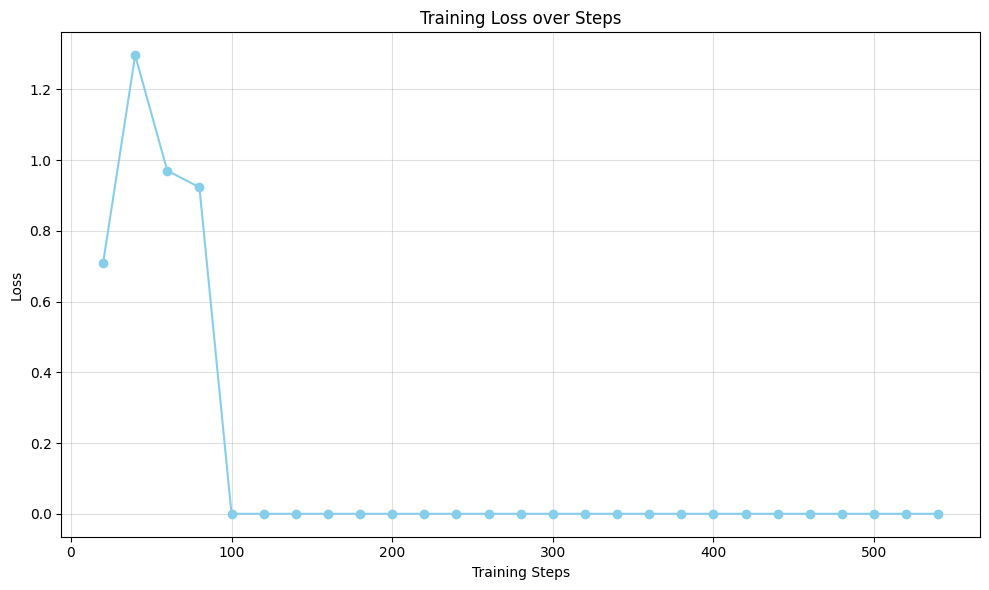


Generating graphs for: Casual — forced FP32 dtype


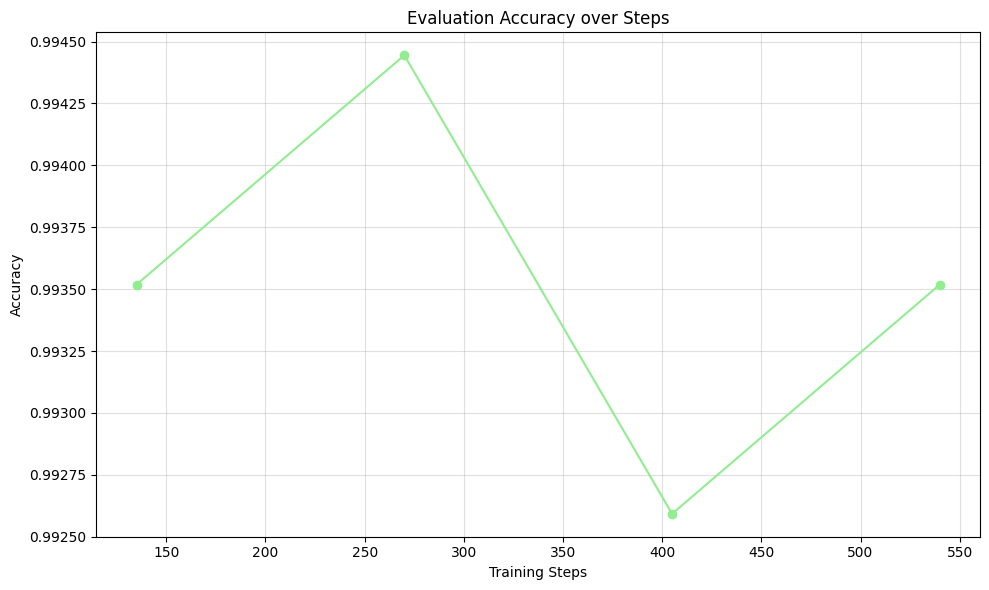

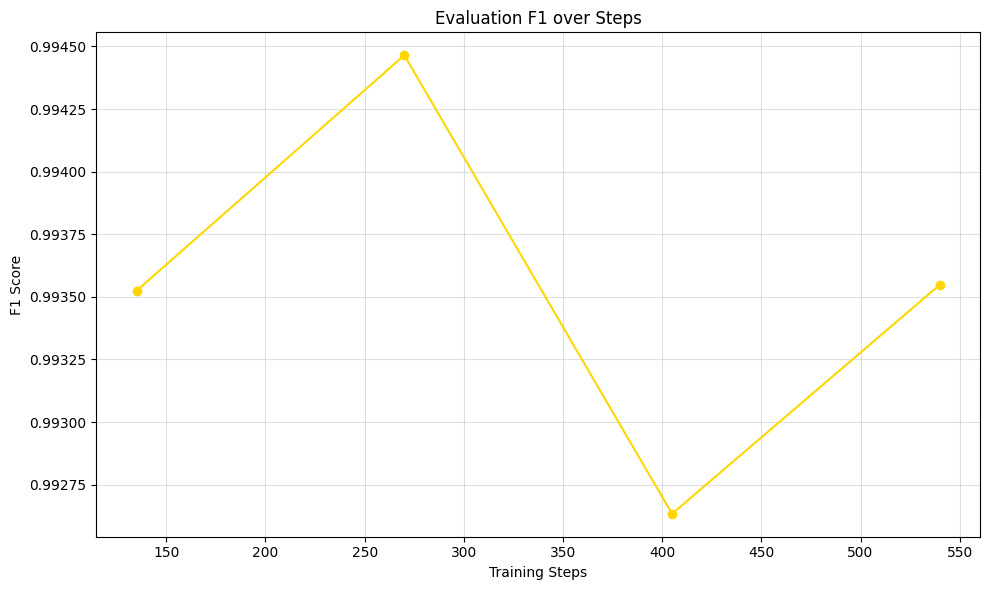

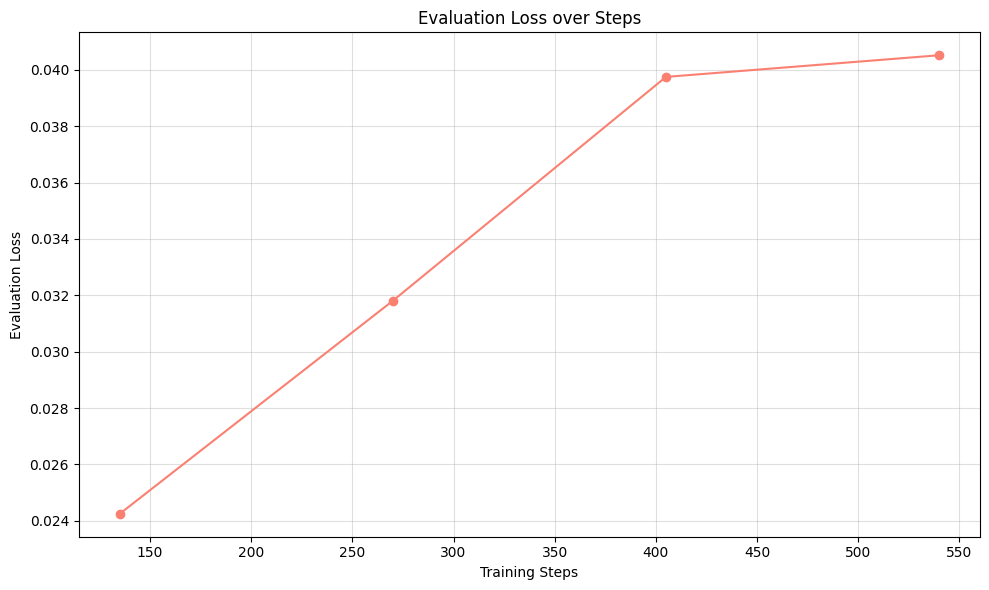

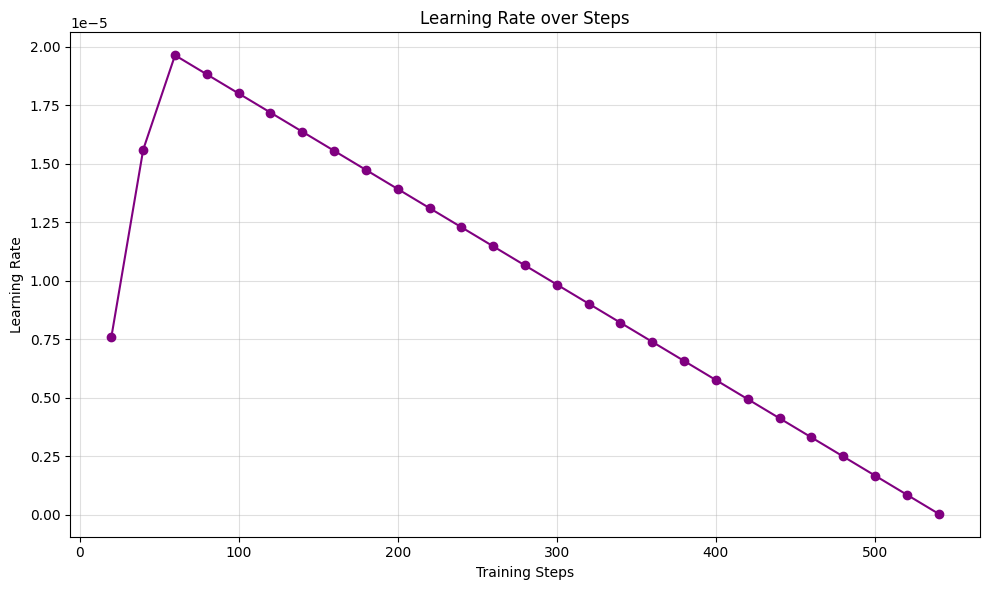

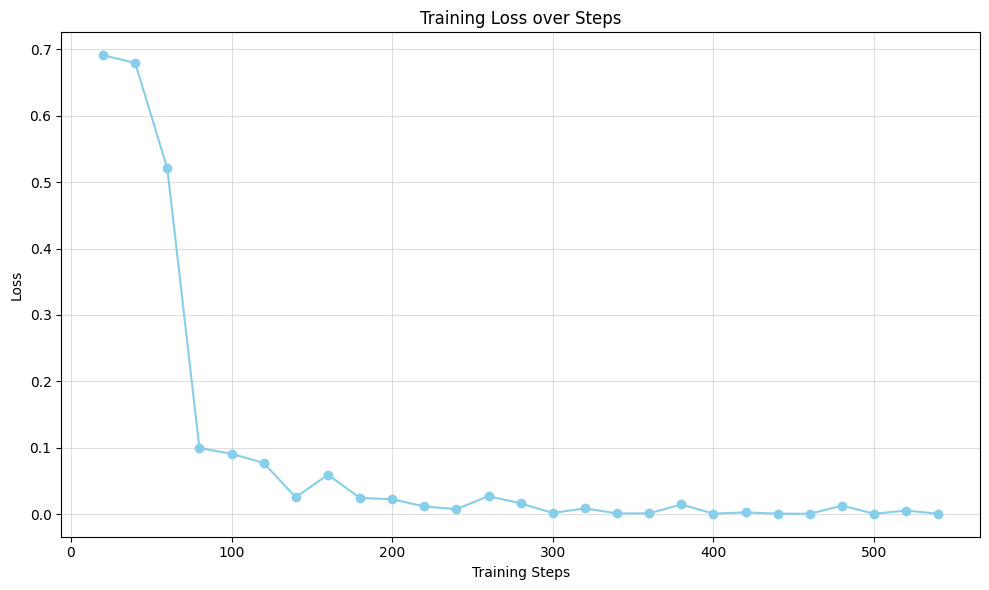


Created: /content/casual_initial_graphs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [4]:
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# ============================================================
# OUTPUT FOLDERS
# ============================================================

artifact_dir = "/content/casual_initial_results"

prelim_graph_dir = os.path.join(
    artifact_dir,
    "prelim_no_forced_dtype"
)

dtype_graph_dir = os.path.join(
    artifact_dir,
    "forced_fp32"
)

os.makedirs(prelim_graph_dir, exist_ok=True)
os.makedirs(dtype_graph_dir, exist_ok=True)

# ============================================================
# PREPARE LOG HISTORY
# ============================================================

def prepare_history(history):
    history_df = pd.DataFrame(history)

    # Training rows contain "loss" but not "eval_loss"
    train_df = history_df[
        history_df["loss"].notna()
    ].copy() if "loss" in history_df.columns else pd.DataFrame()

    # Evaluation rows contain "eval_loss"
    eval_df = history_df[
        history_df["eval_loss"].notna()
    ].copy() if "eval_loss" in history_df.columns else pd.DataFrame()

    # Remove the duplicate final evaluation at the same step
    if not eval_df.empty:
        eval_df = eval_df.drop_duplicates(
            subset="step",
            keep="first"
        )

    if not train_df.empty:
        train_df = train_df.drop_duplicates(
            subset="step",
            keep="first"
        )

    return train_df, eval_df


broken_train, broken_eval = prepare_history(broken_history)
fixed_train, fixed_eval = prepare_history(fixed_history)

# Display the exact logged values
print("NO FORCED DTYPE — EVALUATION LOGS")
display(
    broken_eval[
        [
            column for column in
            ["step", "eval_accuracy", "eval_f1", "eval_loss"]
            if column in broken_eval.columns
        ]
    ]
)

print("FORCED FP32 — EVALUATION LOGS")
display(
    fixed_eval[
        [
            column for column in
            ["step", "eval_accuracy", "eval_f1", "eval_loss"]
            if column in fixed_eval.columns
        ]
    ]
)

# ============================================================
# GENERAL GRAPH FUNCTION
# ============================================================

def create_graph(
    dataframe,
    y_column,
    title,
    y_label,
    color,
    output_path
):
    plt.figure(figsize=(10, 6))

    if (
        dataframe.empty
        or y_column not in dataframe.columns
        or dataframe[y_column].dropna().empty
    ):
        plt.text(
            0.5,
            0.5,
            f"No finite {y_label.lower()} values were logged",
            horizontalalignment="center",
            verticalalignment="center",
            transform=plt.gca().transAxes,
            fontsize=13
        )
    else:
        valid_data = dataframe.dropna(
            subset=["step", y_column]
        )

        plt.plot(
            valid_data["step"],
            valid_data[y_column],
            marker="o",
            color=color
        )

    plt.title(title)
    plt.xlabel("Training Steps")
    plt.ylabel(y_label)
    plt.grid(True, alpha=0.4)
    plt.tight_layout()

    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

# ============================================================
# CREATE FIVE GRAPHS FOR ONE RUN
# ============================================================

def generate_run_graphs(
    train_df,
    eval_df,
    output_directory,
    run_label
):
    print("\nGenerating graphs for:", run_label)

    # 1. Evaluation accuracy
    create_graph(
        dataframe=eval_df,
        y_column="eval_accuracy",
        title="Evaluation Accuracy over Steps",
        y_label="Accuracy",
        color="lightgreen",
        output_path=os.path.join(
            output_directory,
            "eval_accuracy.png"
        )
    )

    # 2. Evaluation F1
    create_graph(
        dataframe=eval_df,
        y_column="eval_f1",
        title="Evaluation F1 over Steps",
        y_label="F1 Score",
        color="gold",
        output_path=os.path.join(
            output_directory,
            "eval_f1.png"
        )
    )

    # 3. Evaluation loss
    create_graph(
        dataframe=eval_df,
        y_column="eval_loss",
        title="Evaluation Loss over Steps",
        y_label="Evaluation Loss",
        color="salmon",
        output_path=os.path.join(
            output_directory,
            "eval_loss.png"
        )
    )

    # 4. Learning rate
    create_graph(
        dataframe=train_df,
        y_column="learning_rate",
        title="Learning Rate over Steps",
        y_label="Learning Rate",
        color="purple",
        output_path=os.path.join(
            output_directory,
            "learning_rate.png"
        )
    )

    # 5. Training loss
    create_graph(
        dataframe=train_df,
        y_column="loss",
        title="Training Loss over Steps",
        y_label="Loss",
        color="skyblue",
        output_path=os.path.join(
            output_directory,
            "training_loss.png"
        )
    )

# ============================================================
# GENERATE KC-MATCHED GRAPH SETS
# ============================================================

generate_run_graphs(
    train_df=broken_train,
    eval_df=broken_eval,
    output_directory=prelim_graph_dir,
    run_label="Casual prelim — no forced dtype"
)

generate_run_graphs(
    train_df=fixed_train,
    eval_df=fixed_eval,
    output_directory=dtype_graph_dir,
    run_label="Casual — forced FP32 dtype"
)

# ============================================================
# SAVE LOGGED VALUES
# ============================================================

broken_train.to_csv(
    os.path.join(
        prelim_graph_dir,
        "training_metrics.csv"
    ),
    index=False
)

broken_eval.to_csv(
    os.path.join(
        prelim_graph_dir,
        "evaluation_metrics.csv"
    ),
    index=False
)

fixed_train.to_csv(
    os.path.join(
        dtype_graph_dir,
        "training_metrics.csv"
    ),
    index=False
)

fixed_eval.to_csv(
    os.path.join(
        dtype_graph_dir,
        "evaluation_metrics.csv"
    ),
    index=False
)

# ============================================================
# ZIP AND DOWNLOAD ALL GRAPHS
# ============================================================

zip_path = shutil.make_archive(
    "/content/casual_initial_graphs",
    "zip",
    artifact_dir
)

print("\nCreated:", zip_path)
files.download(zip_path)